## Import Modules


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

## Importing Dataset

In [5]:
df = pd.read_csv("ecommerce_customer_segmentation_dataset.csv")

print("Shape:", df.shape)
print("\nFirst 5 rows:")
print(df.head())

Shape: (10000, 11)

First 5 rows:
   Invoice_No  Customer_ID Purchase_Date Product_ID Product_Category  \
0      506252        10747    2026-04-15      P1339      Accessories   
1      504684        10561    2026-06-25      P6289           Beauty   
2      501731        10191    2026-08-09      P3853      Accessories   
3      504742        10565    2026-07-09      P4241   Home & Kitchen   
4      504521        10534    2026-06-25      P3155         Clothing   

   Quantity  Unit_Price  Discount_Percent  Final_Price         Country  \
0         1       70.33              24.6        53.03  United Kingdom   
1         3      144.17              16.0       363.31   United States   
2         6       42.24              12.5       221.76        Pakistan   
3         2       77.72               5.2       147.36   United States   
4         2      140.12               7.7       258.66        Pakistan   

     Payment_Method  
0     Bank Transfer  
1     Bank Transfer  
2       Credit Card  


## Cleaning The Data

In [8]:
print(df.info())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Invoice_No        10000 non-null  int64  
 1   Customer_ID       10000 non-null  int64  
 2   Purchase_Date     10000 non-null  object 
 3   Product_ID        10000 non-null  object 
 4   Product_Category  9950 non-null   object 
 5   Quantity          10000 non-null  int64  
 6   Unit_Price        10000 non-null  float64
 7   Discount_Percent  10000 non-null  float64
 8   Final_Price       10000 non-null  float64
 9   Country           9970 non-null   object 
 10  Payment_Method    10000 non-null  object 
dtypes: float64(3), int64(3), object(5)
memory usage: 859.5+ KB
None


In [9]:
print(df.isnull().sum())

Invoice_No           0
Customer_ID          0
Purchase_Date        0
Product_ID           0
Product_Category    50
Quantity             0
Unit_Price           0
Discount_Percent     0
Final_Price          0
Country             30
Payment_Method       0
dtype: int64


In [10]:
df["Product_Category"] = df["Product_Category"].fillna(df["Product_Category"].mode()[0])

df["Country"] = df["Country"].fillna(df["Country"].mode()[0])

In [11]:
print(df.isnull().sum())

Invoice_No          0
Customer_ID         0
Purchase_Date       0
Product_ID          0
Product_Category    0
Quantity            0
Unit_Price          0
Discount_Percent    0
Final_Price         0
Country             0
Payment_Method      0
dtype: int64


In [12]:
df["Country"] = df["Country"].replace({"USA": "United States","U.S.A.": "United States"})

In [13]:
print(df["Country"].value_counts())

Country
Pakistan          4388
United Kingdom    2035
United States     1612
Australia          983
Canada             982
Name: count, dtype: int64


In [14]:
df["Purchase_Date"] = pd.to_datetime(df["Purchase_Date"],errors="coerce")

In [15]:
print(df["Purchase_Date"].dtype)

datetime64[ns]


In [16]:
print(df.describe())

         Invoice_No   Customer_ID               Purchase_Date     Quantity  \
count   10000.00000  10000.000000                       10000  10000.00000   
mean   504999.50000  10592.492300  2026-06-17 19:49:52.320000      3.23660   
min    500000.00000  10001.000000         2025-06-02 00:00:00      1.00000   
25%    502499.75000  10291.000000         2026-05-31 00:00:00      2.00000   
50%    504999.50000  10594.000000         2026-07-09 00:00:00      3.00000   
75%    507499.25000  10898.000000         2026-07-30 00:00:00      4.00000   
max    509999.00000  11200.000000         2026-08-15 00:00:00      7.00000   
std      2886.89568    348.913748                         NaN      1.72108   

         Unit_Price  Discount_Percent   Final_Price  
count  10000.000000      10000.000000  10000.000000  
mean     153.457006         13.193390    439.402720  
min        8.010000          0.000000      5.650000  
25%       58.395000          5.900000    118.985000  
50%      106.455000        

## Feature Engineering

In [18]:
average_purchase_value = df["Final_Price"].mean()

total_sales = df["Final_Price"].sum()

total_customers = df["Customer_ID"].nunique()

purchase_frequency = (
    df.groupby("Customer_ID")["Invoice_No"]
    .nunique()
    .mean()
)

customer_lifetime_value = (
    df.groupby("Customer_ID")["Final_Price"]
    .sum()
    .mean()
)

print("Average Purchase Value:", round(average_purchase_value, 2))
print("Total Sales:", round(total_sales, 2))
print("Total Customers:", total_customers)
print("Average Purchase Frequency:", round(purchase_frequency, 2))
print("Average Customer Lifetime Value:", round(customer_lifetime_value, 2))

Average Purchase Value: 439.4
Total Sales: 4394027.2
Total Customers: 1200
Average Purchase Frequency: 8.33
Average Customer Lifetime Value: 3661.69


## RFM

In [19]:
snapshot_date = df["Purchase_Date"].max() + pd.Timedelta(days=1)

customer_data = df.groupby("Customer_ID").agg(
    Recency=(
        "Purchase_Date",
        lambda x: (snapshot_date - x.max()).days
    ),
    
    Frequency=(
        "Invoice_No",
        "nunique"
    ),
    
    Monetary=(
        "Final_Price",
        "sum"
    ),
    
    Avg_Purchase_Value=(
        "Final_Price",
        "mean"
    )
).reset_index()

print(customer_data.head())

   Customer_ID  Recency  Frequency  Monetary  Avg_Purchase_Value
0        10001        4         15   4321.11          288.074000
1        10002      177          6    909.16          151.526667
2        10003       58          3    437.60          145.866667
3        10004       40          7   1306.76          186.680000
4        10005       11          8   2571.47          321.433750


In [20]:
print(
    customer_data[
        ["Recency", "Frequency", "Monetary"]
    ].describe()
)

           Recency    Frequency      Monetary
count  1200.000000  1200.000000   1200.000000
mean     54.725833     8.333333   3661.689333
std      70.123582     6.358924   4379.408259
min       1.000000     1.000000     10.380000
25%       5.000000     3.000000    734.372500
50%      23.000000     6.000000   1845.325000
75%      83.000000    12.000000   4819.012500
max     397.000000    28.000000  24650.260000


In [21]:
features = [
    "Recency",
    "Frequency",
    "Monetary"
]

X = customer_data[features]

print(X.head())

   Recency  Frequency  Monetary
0        4         15   4321.11
1      177          6    909.16
2       58          3    437.60
3       40          7   1306.76
4       11          8   2571.47


In [22]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

print(X_scaled[:5])

[[-0.72367926  1.04883245  0.15063578]
 [ 1.74442238 -0.36709136 -0.62877831]
 [ 0.04671084 -0.83906596 -0.73649985]
 [-0.21008586 -0.20976649 -0.53795194]
 [-0.62381388 -0.05244162 -0.24904595]]


In [23]:
inertia = []

for k in range(2, 11):
    
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    
    kmeans.fit(X_scaled)
    
    inertia.append(kmeans.inertia_)

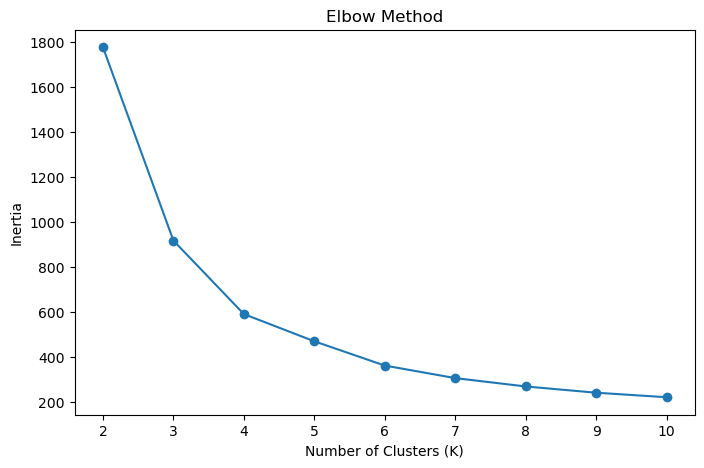

In [24]:
plt.figure(figsize=(8, 5))

plt.plot(
    range(2, 11),
    inertia,
    marker="o"
)

plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.title("Elbow Method")

plt.xticks(range(2, 11))

plt.show()

In [25]:
kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

customer_data["Cluster"] = kmeans.fit_predict(X_scaled)

print(customer_data.head())

   Customer_ID  Recency  Frequency  Monetary  Avg_Purchase_Value  Cluster
0        10001        4         15   4321.11          288.074000        0
1        10002      177          6    909.16          151.526667        1
2        10003       58          3    437.60          145.866667        0
3        10004       40          7   1306.76          186.680000        0
4        10005       11          8   2571.47          321.433750        0


In [26]:
silhouette = silhouette_score(
    X_scaled,
    customer_data["Cluster"]
)

print("Silhouette Score:", round(silhouette, 3))

Silhouette Score: 0.504


In [27]:
cluster_profile = customer_data.groupby("Cluster").agg(
    Customers=("Customer_ID", "count"),
    Recency=("Recency", "mean"),
    Frequency=("Frequency", "mean"),
    Monetary=("Monetary", "mean"),
    Avg_Purchase_Value=("Avg_Purchase_Value", "mean")
).round(2)

print(cluster_profile)

         Customers  Recency  Frequency  Monetary  Avg_Purchase_Value
Cluster                                                             
0              666    24.09       7.42   2344.94              309.43
1              302   161.34       2.63    723.78              269.02
2              232     3.90      18.39  11266.02              615.37


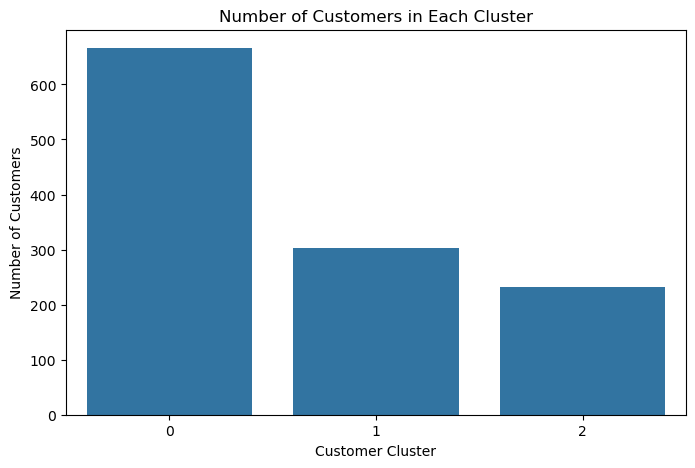

In [28]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=customer_data,
    x="Cluster"
)

plt.title("Number of Customers in Each Cluster")
plt.xlabel("Customer Cluster")
plt.ylabel("Number of Customers")

plt.show()

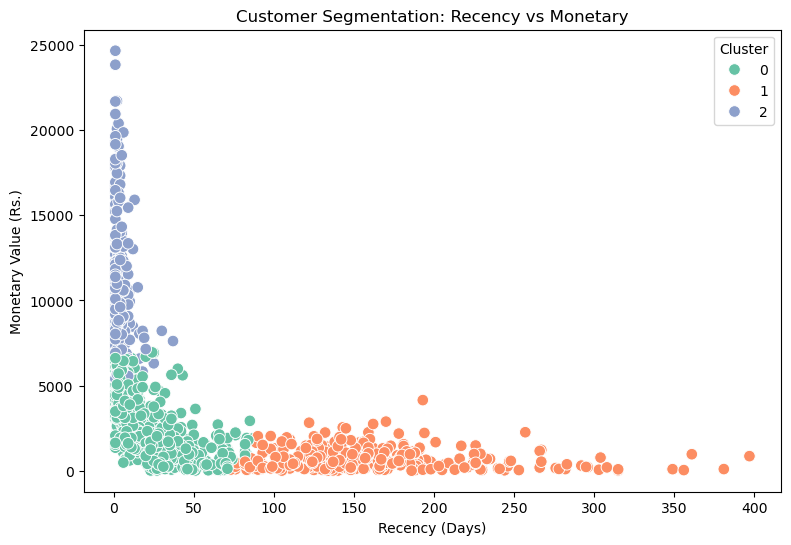

In [29]:
plt.figure(figsize=(9, 6))

sns.scatterplot(
    data=customer_data,
    x="Recency",
    y="Monetary",
    hue="Cluster",
    palette="Set2",
    s=70
)

plt.title("Customer Segmentation: Recency vs Monetary")
plt.xlabel("Recency (Days)")
plt.ylabel("Monetary Value (Rs.)")

plt.show()

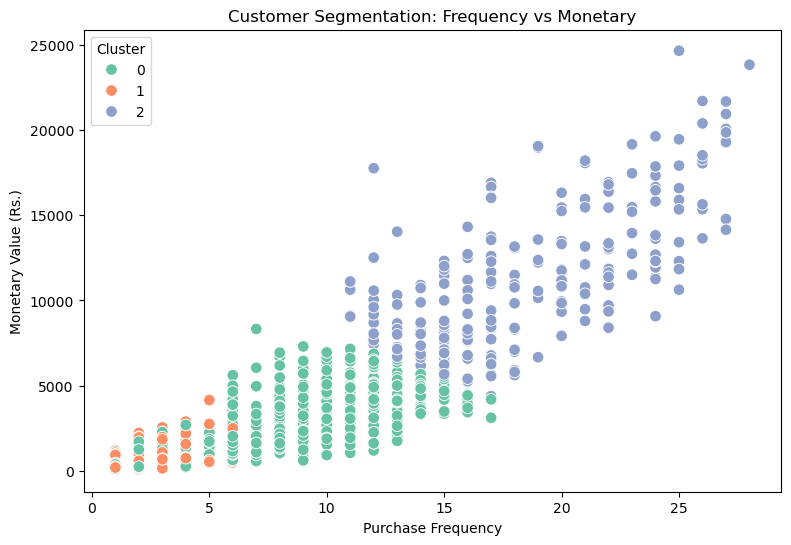

In [31]:
plt.figure(figsize=(9, 6))

sns.scatterplot(
    data=customer_data,
    x="Frequency",
    y="Monetary",
    hue="Cluster",
    palette="Set2",
    s=70
)

plt.title("Customer Segmentation: Frequency vs Monetary")
plt.xlabel("Purchase Frequency")
plt.ylabel("Monetary Value (Rs.)")

plt.show()

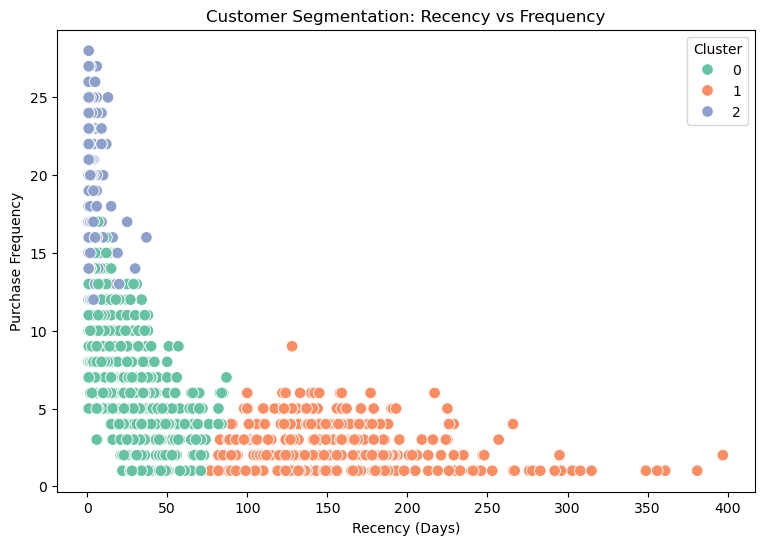

In [32]:
plt.figure(figsize=(9, 6))

sns.scatterplot(
    data=customer_data,
    x="Recency",
    y="Frequency",
    hue="Cluster",
    palette="Set2",
    s=70
)

plt.title("Customer Segmentation: Recency vs Frequency")
plt.xlabel("Recency (Days)")
plt.ylabel("Purchase Frequency")

plt.show()